# VoxIntel — 10: Results, Diagnosis, and Debugging of Notebooks 07–09

## Goal

This notebook is a **forensic audit** of the three most important downstream notebooks:

- **07 — Upper-Bound Intent Classifier**
- **08 — Error Propagation Analysis**
- **09 — Error Taxonomy**

It does **not** train any new models.

Instead, it answers:

1. Are the saved outputs internally consistent?
2. Which results from 07 are trustworthy?
3. Which results from 08 are trustworthy?
4. Which parts of 09 are broken or suspicious?
5. What should be fixed before moving on?

## Main outcomes

By the end of this notebook, you should have:

- a validated summary of the **trusted** findings from 07 and 08
- a diagnosis of the **broken** or suspicious parts of 09
- a list of concrete fixes to apply before continuing the project


## Cell 0 — Make sure `src` is importable


In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("PROJECT_ROOT:", PROJECT_ROOT)


PROJECT_ROOT: c:\Users\ACER\OneDrive\Desktop\VoxIntel


## Cell 1 — Imports


In [2]:
import json
import ast
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

sns.set_theme(style="whitegrid")


## Cell 2 — Paths


In [3]:
REPORTS_DIR = PROJECT_ROOT / "reports"
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"

PATHS = {
    "classification_report": REPORTS_DIR / "classification_report.json",
    "intent_validation_predictions": REPORTS_DIR / "intent_validation_predictions.csv",
    "metric_comparison": REPORTS_DIR / "metric_comparison.csv",
    "confidence_comparison": REPORTS_DIR / "confidence_comparison.csv",
    "error_propagation_results": REPORTS_DIR / "error_propagation_results.csv",
    "intent_predictions_ground_truth": REPORTS_DIR / "intent_predictions_ground_truth.csv",
    "intent_predictions_baseline": REPORTS_DIR / "intent_predictions_baseline.csv",
    "intent_predictions_finetuned": REPORTS_DIR / "intent_predictions_finetuned.csv",
    "per_intent_f1_comparison": REPORTS_DIR / "per_intent_f1_comparison.csv",
    "per_scenario_f1_comparison": REPORTS_DIR / "per_scenario_f1_comparison.csv",
    "recovery_summary": REPORTS_DIR / "recovery_summary.csv",
    "error_taxonomy_dataset": REPORTS_DIR / "error_taxonomy_dataset.csv",
    "error_type_distribution": REPORTS_DIR / "error_type_distribution.csv",
    "error_impact_matrix": REPORTS_DIR / "error_impact_matrix.csv",
    "intent_fragility": REPORTS_DIR / "intent_fragility.csv",
    "failure_gallery": REPORTS_DIR / "failure_gallery.csv",
}

for name, path in PATHS.items():
    print(f"{name:28s} -> {'FOUND' if path.exists() else 'MISSING'} | {path}")


classification_report        -> FOUND | c:\Users\ACER\OneDrive\Desktop\VoxIntel\reports\classification_report.json
intent_validation_predictions -> FOUND | c:\Users\ACER\OneDrive\Desktop\VoxIntel\reports\intent_validation_predictions.csv
metric_comparison            -> FOUND | c:\Users\ACER\OneDrive\Desktop\VoxIntel\reports\metric_comparison.csv
confidence_comparison        -> FOUND | c:\Users\ACER\OneDrive\Desktop\VoxIntel\reports\confidence_comparison.csv
error_propagation_results    -> FOUND | c:\Users\ACER\OneDrive\Desktop\VoxIntel\reports\error_propagation_results.csv
intent_predictions_ground_truth -> FOUND | c:\Users\ACER\OneDrive\Desktop\VoxIntel\reports\intent_predictions_ground_truth.csv
intent_predictions_baseline  -> FOUND | c:\Users\ACER\OneDrive\Desktop\VoxIntel\reports\intent_predictions_baseline.csv
intent_predictions_finetuned -> FOUND | c:\Users\ACER\OneDrive\Desktop\VoxIntel\reports\intent_predictions_finetuned.csv
per_intent_f1_comparison     -> FOUND | c:\Users\ACE

## Cell 3 — Load available outputs


In [4]:
def load_csv_if_exists(path):
    return pd.read_csv(path) if path.exists() else None

metric_comparison_df = load_csv_if_exists(PATHS["metric_comparison"])
confidence_comparison_df = load_csv_if_exists(PATHS["confidence_comparison"])
error_propagation_results_df = load_csv_if_exists(PATHS["error_propagation_results"])
intent_predictions_ground_truth_df = load_csv_if_exists(PATHS["intent_predictions_ground_truth"])
intent_predictions_baseline_df = load_csv_if_exists(PATHS["intent_predictions_baseline"])
intent_predictions_finetuned_df = load_csv_if_exists(PATHS["intent_predictions_finetuned"])
per_intent_f1_comparison_df = load_csv_if_exists(PATHS["per_intent_f1_comparison"])
per_scenario_f1_comparison_df = load_csv_if_exists(PATHS["per_scenario_f1_comparison"])
recovery_summary_df = load_csv_if_exists(PATHS["recovery_summary"])
error_taxonomy_dataset_df = load_csv_if_exists(PATHS["error_taxonomy_dataset"])
error_type_distribution_df = load_csv_if_exists(PATHS["error_type_distribution"])
error_impact_matrix_df = load_csv_if_exists(PATHS["error_impact_matrix"])
intent_fragility_df = load_csv_if_exists(PATHS["intent_fragility"])
failure_gallery_df = load_csv_if_exists(PATHS["failure_gallery"])
intent_validation_predictions_df = load_csv_if_exists(PATHS["intent_validation_predictions"])

classification_report = None
if PATHS["classification_report"].exists():
    with open(PATHS["classification_report"], "r", encoding="utf-8") as f:
        classification_report = json.load(f)

print("Loaded available outputs.")


Loaded available outputs.


## Cell 4 — Notebook 07: top-line metrics and class imbalance diagnosis


In [5]:
if classification_report is None or intent_validation_predictions_df is None:
    raise ValueError("Notebook 07 outputs are missing. Need classification_report.json and intent_validation_predictions.csv.")

class_rows = []
for label_name, stats in classification_report.items():
    if isinstance(stats, dict) and "support" in stats and label_name not in ["macro avg", "weighted avg"]:
        class_rows.append({
            "intent": label_name,
            "support": float(stats["support"]),
            "precision": float(stats["precision"]),
            "recall": float(stats["recall"]),
            "f1": float(stats["f1-score"]),
        })

class_report_df = pd.DataFrame(class_rows)
class_report_df = class_report_df[class_report_df["support"] > 0].copy()

n_zero_f1 = int(((class_report_df["support"] > 0) & (class_report_df["f1"] == 0)).sum())
summary_07 = {
    "n_validation_rows": len(intent_validation_predictions_df),
    "accuracy": float(intent_validation_predictions_df["correct"].mean()),
    "top3_accuracy": float(intent_validation_predictions_df["top3_correct"].mean()),
    "mean_confidence": float(intent_validation_predictions_df["confidence"].mean()),
    "median_confidence": float(intent_validation_predictions_df["confidence"].median()),
    "n_intents_with_support": int(len(class_report_df)),
    "n_zero_f1_intents": n_zero_f1,
}

summary_07


{'n_validation_rows': 2032,
 'accuracy': 0.8681102362204725,
 'top3_accuracy': 0.9483267716535433,
 'mean_confidence': 0.9204777459670276,
 'median_confidence': 0.9807604000000001,
 'n_intents_with_support': 70,
 'n_zero_f1_intents': 14}

## Cell 5 — Notebook 07: weakest and strongest intents


In [6]:
worst_07_df = class_report_df.sort_values(["f1", "support"]).head(15)
best_07_df = class_report_df[class_report_df["support"] >= 10].sort_values("f1", ascending=False).head(15)

print("Worst intents in Notebook 07 (support > 0):")
display(worst_07_df)

print("Best intents in Notebook 07 (support >= 10):")
display(best_07_df)


Worst intents in Notebook 07 (support > 0):


,intent,support,precision,recall,f1
11,cleaning,1.0,0.000000,0.000000,0.000000
26,factoid,1.0,0.000000,0.000000,0.000000
28,general_greet,1.0,0.000000,0.000000,0.000000
31,greet,1.0,0.000000,0.000000,0.000000
33,hue_lightoff,1.0,0.000000,0.000000,0.000000
34,hue_lightup,1.0,0.000000,0.000000,0.000000
60,post,1.0,0.000000,0.000000,0.000000
14,cooking_query,2.0,0.000000,0.000000,0.000000
49,music_dislikeness,2.0,0.000000,0.000000,0.000000
59,podcasts,2.0,0.000000,0.000000,0.000000


Best intents in Notebook 07 (support >= 10):


,intent,support,precision,recall,f1
86,transport_traffic,22.0,1.000000,1.000000,1.000000
36,iot_coffee,14.0,1.000000,1.000000,1.000000
29,general_joke,15.0,1.000000,1.000000,1.000000
61,qa_currency,32.0,0.969697,1.000000,0.984615
84,transport_taxi,27.0,0.964286,1.000000,0.981818
38,iot_hue_lightdim,17.0,1.000000,0.941176,0.969697
9,calendar_remove,47.0,0.958333,0.978723,0.968421
2,alarm_remove,14.0,1.000000,0.928571,0.962963
24,email_sendemail,63.0,0.983333,0.936508,0.959350
10,calendar_set,130.0,0.960938,0.946154,0.953488


## Cell 6 — Notebook 08: central experiment summary


In [7]:
if metric_comparison_df is None or confidence_comparison_df is None or recovery_summary_df is None:
    raise ValueError("Notebook 08 outputs are missing. Need metric_comparison.csv, confidence_comparison.csv, and recovery_summary.csv.")

print("Metric comparison:")
display(metric_comparison_df)

print("Confidence comparison:")
display(confidence_comparison_df)

print("Recovery summary:")
display(recovery_summary_df)


Metric comparison:


,transcript_source,n_samples,accuracy,precision_macro,recall_macro,macro_f1,top3_accuracy,mean_confidence,median_confidence
0,ground_truth,8688,0.857735,0.696729,0.715841,0.703180,0.944406,0.922548,0.980201
1,baseline,8688,0.384899,0.404243,0.283904,0.308180,0.515654,0.734901,0.837562
2,finetuned,8688,0.734346,0.572839,0.570868,0.555436,0.845419,0.861017,0.968617


Confidence comparison:


,transcript_source,mean_confidence,median_confidence,std_confidence,mean_confidence_correct,mean_confidence_incorrect
0,ground_truth,0.922548,0.980201,0.144072,0.951367,0.748795
1,baseline,0.734901,0.837562,0.261510,0.876856,0.646074
2,finetuned,0.861017,0.968617,0.204988,0.927134,0.678251


Recovery summary:


,recovery_status,samples,rate
0,recovered,3430,0.394797
1,always_correct,2950,0.339549
2,still_broken,1914,0.220304
3,regressed,394,0.045350


## Cell 7 — Notebook 08: compute recovery deltas explicitly


In [8]:
gt_row = metric_comparison_df.loc[metric_comparison_df["transcript_source"] == "ground_truth"].iloc[0]
baseline_row = metric_comparison_df.loc[metric_comparison_df["transcript_source"] == "baseline"].iloc[0]
finetuned_row = metric_comparison_df.loc[metric_comparison_df["transcript_source"] == "finetuned"].iloc[0]

recovery_diagnostics_df = pd.DataFrame([
    {
        "metric": "accuracy",
        "ground_truth": gt_row["accuracy"],
        "baseline": baseline_row["accuracy"],
        "finetuned": finetuned_row["accuracy"],
        "drop_baseline_from_gt": gt_row["accuracy"] - baseline_row["accuracy"],
        "drop_finetuned_from_gt": gt_row["accuracy"] - finetuned_row["accuracy"],
        "recovery_over_baseline": finetuned_row["accuracy"] - baseline_row["accuracy"],
    },
    {
        "metric": "macro_f1",
        "ground_truth": gt_row["macro_f1"],
        "baseline": baseline_row["macro_f1"],
        "finetuned": finetuned_row["macro_f1"],
        "drop_baseline_from_gt": gt_row["macro_f1"] - baseline_row["macro_f1"],
        "drop_finetuned_from_gt": gt_row["macro_f1"] - finetuned_row["macro_f1"],
        "recovery_over_baseline": finetuned_row["macro_f1"] - baseline_row["macro_f1"],
    },
    {
        "metric": "top3_accuracy",
        "ground_truth": gt_row["top3_accuracy"],
        "baseline": baseline_row["top3_accuracy"],
        "finetuned": finetuned_row["top3_accuracy"],
        "drop_baseline_from_gt": gt_row["top3_accuracy"] - baseline_row["top3_accuracy"],
        "drop_finetuned_from_gt": gt_row["top3_accuracy"] - finetuned_row["top3_accuracy"],
        "recovery_over_baseline": finetuned_row["top3_accuracy"] - baseline_row["top3_accuracy"],
    },
])

display(recovery_diagnostics_df)


,metric,ground_truth,baseline,finetuned,drop_baseline_from_gt,drop_finetuned_from_gt,recovery_over_baseline
0,accuracy,0.857735,0.384899,0.734346,0.472836,0.123389,0.349448
1,macro_f1,0.703180,0.308180,0.555436,0.395000,0.147744,0.247256
2,top3_accuracy,0.944406,0.515654,0.845419,0.428752,0.098987,0.329765


## Cell 8 — Notebook 08: validate prediction files against summary metrics


In [9]:
required_prediction_dfs = {
    "ground_truth": intent_predictions_ground_truth_df,
    "baseline": intent_predictions_baseline_df,
    "finetuned": intent_predictions_finetuned_df,
}
for name, df in required_prediction_dfs.items():
    if df is None:
        raise ValueError(f"Missing prediction file for {name}")

consistency_rows = []
for source_name, df in required_prediction_dfs.items():
    metric_row = metric_comparison_df.loc[metric_comparison_df["transcript_source"] == source_name].iloc[0]
    consistency_rows.append({
        "transcript_source": source_name,
        "csv_accuracy": float(df["correct"].mean()),
        "metric_accuracy": float(metric_row["accuracy"]),
        "accuracy_match": math.isclose(float(df["correct"].mean()), float(metric_row["accuracy"]), rel_tol=0, abs_tol=1e-9),
        "csv_top3_accuracy": float(df["top3_correct"].mean()),
        "metric_top3_accuracy": float(metric_row["top3_accuracy"]),
        "top3_match": math.isclose(float(df["top3_correct"].mean()), float(metric_row["top3_accuracy"]), rel_tol=0, abs_tol=1e-9),
    })

consistency_df = pd.DataFrame(consistency_rows)
display(consistency_df)


,transcript_source,csv_accuracy,metric_accuracy,accuracy_match,csv_top3_accuracy,metric_top3_accuracy,top3_match
0,ground_truth,0.857735,0.857735,True,0.944406,0.944406,True
1,baseline,0.384899,0.384899,True,0.515654,0.515654,True
2,finetuned,0.734346,0.734346,True,0.845419,0.845419,True


## Cell 9 — Notebook 08: suspicion check on per-intent F1 table


In [10]:
if per_intent_f1_comparison_df is None:
    raise ValueError("Missing per_intent_f1_comparison.csv")

suspicious_per_intent = (
    per_intent_f1_comparison_df["ground_truth_f1"].nunique() <= 3
    or (per_intent_f1_comparison_df["ground_truth_f1"] == 1.0).mean() > 0.5
)

print("Suspicious per-intent F1 structure:", suspicious_per_intent)
print("Ground-truth F1 unique values:", per_intent_f1_comparison_df["ground_truth_f1"].nunique())
print("Fraction of intents with ground_truth_f1 == 1.0:", (per_intent_f1_comparison_df["ground_truth_f1"] == 1.0).mean())

display(per_intent_f1_comparison_df.head(20))


Suspicious per-intent F1 structure: False
Ground-truth F1 unique values: 45
Fraction of intents with ground_truth_f1 == 1.0: 0.17142857142857143


,intent,ground_truth_f1,n_samples_ground_truth,baseline_f1,finetuned_f1,baseline_drop,finetuned_drop,recovery
0,transport_taxi,1.000000,97,0.018145,0.136713,0.981855,0.863287,0.118568
1,audio_volume_down,1.000000,95,0.026357,0.104283,0.973643,0.895717,0.077926
2,qa_currency,1.000000,108,0.028947,0.085714,0.971053,0.914286,0.056767
3,transport_traffic,1.000000,87,0.032051,0.003457,0.967949,0.996543,-0.028594
4,transport_ticket,1.000000,101,0.036092,0.243655,0.963908,0.756345,0.207563
5,email_addcontact,1.000000,20,0.036364,0.473684,0.963636,0.526316,0.437321
6,iot_wemo_off,1.000000,26,0.042424,0.000000,0.957576,1.000000,-0.042424
7,iot_hue_lightup,1.000000,49,0.049145,1.000000,0.950855,0.000000,0.950855
8,music_settings,1.000000,22,0.052910,0.096552,0.947090,0.903448,0.043642
9,iot_coffee,1.000000,68,0.060748,0.064565,0.939252,0.935435,0.003817


## Cell 10 — Notebook 08 diagnosis

This cell writes out the main interpretation of Notebook 08.


In [11]:
notebook_08_diagnosis = {
    "trusted": [
        "overall accuracy / macro-F1 / top-3 comparisons across transcript sources",
        "confidence trend: ground_truth > finetuned > baseline",
        "recovery summary from baseline to fine-tuned ASR",
    ],
    "use_with_caution": [
        "per_intent_f1_comparison.csv may not be true one-vs-rest per-intent F1",
        "intent fragility rankings built on that table may be distorted",
    ],
}
notebook_08_diagnosis


{'trusted': ['overall accuracy / macro-F1 / top-3 comparisons across transcript sources',
  'confidence trend: ground_truth > finetuned > baseline',
  'recovery summary from baseline to fine-tuned ASR'],
 'use_with_caution': ['per_intent_f1_comparison.csv may not be true one-vs-rest per-intent F1',
  'intent fragility rankings built on that table may be distorted']}

## Cell 11 — Notebook 09: basic sanity checks


In [12]:
if error_taxonomy_dataset_df is None or error_type_distribution_df is None or error_impact_matrix_df is None:
    raise ValueError("Notebook 09 outputs are missing.")

sanity_09 = {
    "rows": len(error_taxonomy_dataset_df),
    "baseline_all_no_error": float((error_taxonomy_dataset_df["baseline_primary_error_type"] == "no_error").mean()),
    "finetuned_all_no_error": float((error_taxonomy_dataset_df["finetuned_primary_error_type"] == "no_error").mean()),
    "baseline_exact_match_rate": float((error_taxonomy_dataset_df["baseline_alignment_summary"] == "exact_match").mean()),
    "finetuned_exact_match_rate": float((error_taxonomy_dataset_df["finetuned_alignment_summary"] == "exact_match").mean()),
    "baseline_text_diff_rate": float((error_taxonomy_dataset_df["baseline_transcript"].astype(str).str.lower() != error_taxonomy_dataset_df["ground_truth"].astype(str).str.lower()).mean()),
    "finetuned_text_diff_rate": float((error_taxonomy_dataset_df["finetuned_transcript"].astype(str).str.lower() != error_taxonomy_dataset_df["ground_truth"].astype(str).str.lower()).mean()),
}

sanity_09


{'rows': 8688,
 'baseline_all_no_error': 1.0,
 'finetuned_all_no_error': 1.0,
 'baseline_exact_match_rate': 1.0,
 'finetuned_exact_match_rate': 1.0,
 'baseline_text_diff_rate': 0.9349677716390423,
 'finetuned_text_diff_rate': 0.7879834254143646}

## Cell 12 — Notebook 09: show the contradiction directly


In [13]:
contradiction_df = error_taxonomy_dataset_df.loc[
    (error_taxonomy_dataset_df["baseline_transcript"].astype(str).str.lower() != error_taxonomy_dataset_df["ground_truth"].astype(str).str.lower())
    & (error_taxonomy_dataset_df["baseline_primary_error_type"] == "no_error"),
    [
        "intent", "ground_truth", "baseline_transcript",
        "baseline_primary_error_type", "baseline_alignment_summary",
        "baseline_correct", "baseline_confidence",
    ]
].head(20)

display(contradiction_df)


,intent,ground_truth,baseline_transcript,baseline_primary_error_type,baseline_alignment_summary,baseline_correct,baseline_confidence
0,qa_currency,siri what is one american dollar in japanese yen,SERY WHAT IS ONE AMERICAN DULL IN JAPANESIAN,no_error,exact_match,False,0.571965
1,qa_currency,siri what is one american dollar in japanese yen,SERIE WAYS ONE AMERICAN BULLEN JOP IN HES YEN,no_error,exact_match,False,0.286248
2,email_query,how many unread emails do i have,HOW MANY A RED AMALS DO I HAVE,no_error,exact_match,False,0.257733
3,email_query,how many unread emails do i have,HOW MANY AN RED OMIN US TO I HAVE,no_error,exact_match,False,0.190725
4,email_query,how many unread emails do i have,HOW MANY UNDRED ENOLS DO I HAVE,no_error,exact_match,False,0.195282
5,email_query,how many unread emails do i have,HOW MANY HUNDRED GUINOTS DO I HAVE,no_error,exact_match,False,0.951244
6,email_query,how many unread emails do i have,HOW MANY ANRITIN IMALES DO I HAVE,no_error,exact_match,False,0.504026
7,email_query,how many unread emails do i have,HOW MYI ANGREAT HEMORGE DOR AHEAD,no_error,exact_match,False,0.931720
8,takeaway_order,order me chinese food,OR DE MICINESE FOUD,no_error,exact_match,False,0.814839
9,takeaway_order,order me chinese food,ORDINY CHINESE FOOD,no_error,exact_match,True,0.940991


## Cell 13 — Notebook 09: inspect saved error type tables


In [14]:
print("Error type distribution:")
display(error_type_distribution_df)

print("Error impact matrix:")
display(error_impact_matrix_df)

print("Intent fragility:")
display(intent_fragility_df.head(20))


Error type distribution:


,error_type,baseline,finetuned,delta_finetuned_minus_baseline
0,no_error,8688,8688,0


Error impact matrix:


,system,error_type,samples,intent_failure_rate,low_impact_rate,mean_edits,mean_overlap
0,baseline,no_error,8688,0.615101,0.0,0.0,1.0
1,finetuned,no_error,8688,0.265654,0.0,0.0,1.0


Intent fragility:


,intent,n_samples,baseline_failure_rate,finetuned_failure_rate,baseline_mean_edits,finetuned_mean_edits,recovery_rate
0,hue_lightoff,9,1.000000,1.000000,0.0,0.0,0.000000
1,factoid,14,1.000000,1.000000,0.0,0.0,0.000000
2,music_dislikeness,5,1.000000,1.000000,0.0,0.0,0.000000
3,music,39,1.000000,1.000000,0.0,0.0,0.000000
4,podcasts,6,1.000000,1.000000,0.0,0.0,0.000000
5,cooking_query,14,1.000000,1.000000,0.0,0.0,0.000000
6,cleaning,8,1.000000,1.000000,0.0,0.0,0.000000
7,general_greet,17,1.000000,1.000000,0.0,0.0,0.000000
8,query,87,1.000000,1.000000,0.0,0.0,0.000000
9,quirky,26,1.000000,1.000000,0.0,0.0,0.000000


## Cell 14 — Diagnose Notebook 09 failure mode


In [15]:
notebook_09_diagnosis = {
    "status": "broken",
    "evidence": [
        "All 8,688 baseline rows are labeled no_error",
        "All 8,688 fine-tuned rows are labeled no_error",
        "Alignment summary is exact_match for every row",
        "But 93.5% of baseline transcripts differ from ground truth",
        "And 78.8% of fine-tuned transcripts differ from ground truth",
    ],
    "likely_root_causes": [
        "tokenization/alignment bug inside analyze_transcript_error()",
        "taxonomy logic producing empty or mismatched token sequences",
        "stale saved taxonomy outputs generated before a patch",
    ],
    "consequence": "Notebook 09 tables and plots are not trustworthy in current form.",
}
notebook_09_diagnosis


{'status': 'broken',
 'evidence': ['All 8,688 baseline rows are labeled no_error',
  'All 8,688 fine-tuned rows are labeled no_error',
  'Alignment summary is exact_match for every row',
  'But 93.5% of baseline transcripts differ from ground truth',
  'And 78.8% of fine-tuned transcripts differ from ground truth'],
 'likely_root_causes': ['tokenization/alignment bug inside analyze_transcript_error()',
  'taxonomy logic producing empty or mismatched token sequences',
  'stale saved taxonomy outputs generated before a patch'],
 'consequence': 'Notebook 09 tables and plots are not trustworthy in current form.'}

## Cell 15 — Visual summary of trusted Notebook 08 results


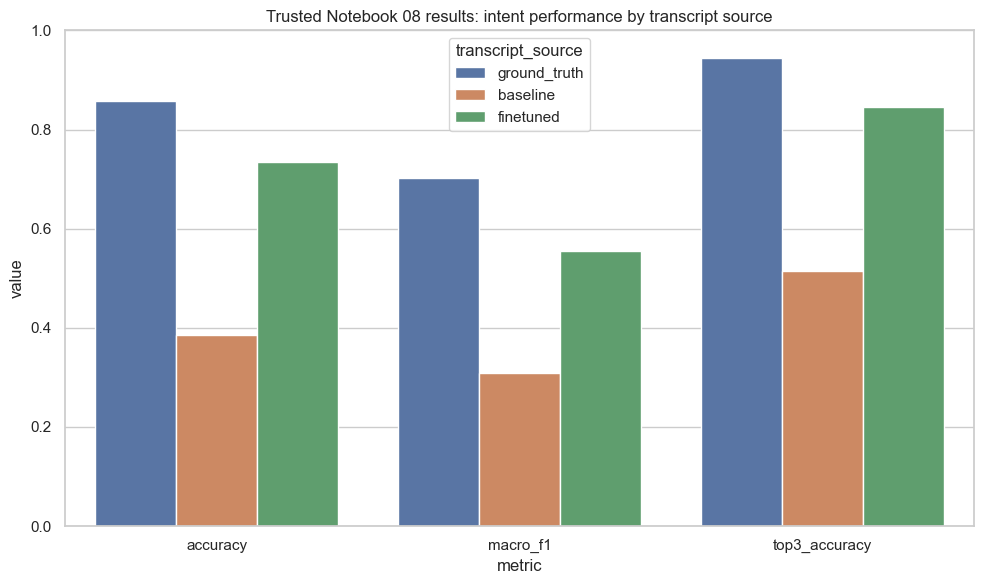

In [16]:
plot_df = metric_comparison_df.melt(
    id_vars="transcript_source",
    value_vars=["accuracy", "macro_f1", "top3_accuracy"],
    var_name="metric",
    value_name="value",
)

plt.figure(figsize=(10, 6))
sns.barplot(data=plot_df, x="metric", y="value", hue="transcript_source")
plt.ylim(0, 1.0)
plt.title("Trusted Notebook 08 results: intent performance by transcript source")
plt.tight_layout()
plt.show()


## Cell 16 — Visual summary of Notebook 07 long-tail weakness


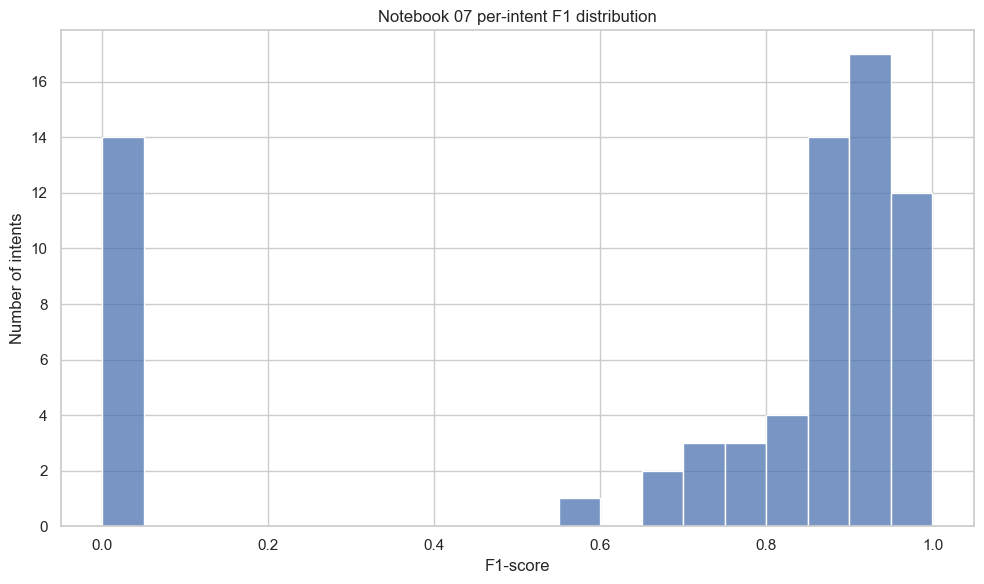

In [17]:
plt.figure(figsize=(10, 6))
sns.histplot(class_report_df["f1"], bins=20)
plt.title("Notebook 07 per-intent F1 distribution")
plt.xlabel("F1-score")
plt.ylabel("Number of intents")
plt.tight_layout()
plt.show()


## Cell 17 — Final verdict


In [18]:
final_verdict_df = pd.DataFrame([
    {
        "notebook": "07_upper_bound_intent_classifier",
        "status": "valid",
        "main_takeaway": "Strong text-only upper bound, but minority intents remain weak.",
    },
    {
        "notebook": "08_error_propagation_analysis",
        "status": "mostly valid",
        "main_takeaway": "Core downstream result is strong: better ASR improves intent understanding.",
    },
    {
        "notebook": "09_error_taxonomy",
        "status": "invalid",
        "main_takeaway": "Current taxonomy outputs are broken and should not be used in the report.",
    },
])

display(final_verdict_df)


,notebook,status,main_takeaway
0,07_upper_bound_intent_classifier,valid,"Strong text-only upper bound, but minority int..."
1,08_error_propagation_analysis,mostly valid,Core downstream result is strong: better ASR i...
2,09_error_taxonomy,invalid,Current taxonomy outputs are broken and should...


## Cell 18 — Concrete next fixes before moving forward


In [19]:
next_fixes = [
    "Fix Notebook 09 tokenization/alignment so transcripts no longer collapse to no_error/exact_match.",
    "Re-run Notebook 09 and regenerate error_type_distribution.csv, error_impact_matrix.csv, intent_fragility.csv, and failure_gallery.csv.",
    "Optionally patch Notebook 08 per-intent F1 to use one-vs-rest F1 rather than grouped macro-F1.",
    "Keep Notebook 07 and 08 core findings for the report; exclude current Notebook 09 findings until fixed.",
]

for i, item in enumerate(next_fixes, 1):
    print(f"{i}. {item}")


1. Fix Notebook 09 tokenization/alignment so transcripts no longer collapse to no_error/exact_match.
2. Re-run Notebook 09 and regenerate error_type_distribution.csv, error_impact_matrix.csv, intent_fragility.csv, and failure_gallery.csv.
3. Optionally patch Notebook 08 per-intent F1 to use one-vs-rest F1 rather than grouped macro-F1.
4. Keep Notebook 07 and 08 core findings for the report; exclude current Notebook 09 findings until fixed.


## Cell 19 — Save diagnosis artifacts


In [20]:
diagnosis_summary = {
    "notebook_07": summary_07,
    "notebook_08": notebook_08_diagnosis,
    "notebook_09": notebook_09_diagnosis,
}

with open(REPORTS_DIR / "debugging_summary_07_08_09.json", "w", encoding="utf-8") as f:
    json.dump(diagnosis_summary, f, indent=2)

final_verdict_df.to_csv(REPORTS_DIR / "debugging_verdict_07_08_09.csv", index=False)
print("Saved debugging_summary_07_08_09.json and debugging_verdict_07_08_09.csv")


Saved debugging_summary_07_08_09.json and debugging_verdict_07_08_09.csv


## Conclusion

A forensic audit of NB07–09 that re-derives each notebook's headline numbers from its saved artifacts and checks them for internal consistency. Its main contribution is catching the silent NB09 taxonomy bug before it reached the report.

**Key results**
- NB07 upper bound reproduced — accuracy `0.8681` on 2,032 validation rows, top-3 `0.9483`; 14 of 70 supported intents have F1 = 0 (long-tail weakness)
- NB08 verified — CSV-vs-summary accuracy matches for all three sources (ground-truth `0.8577` / baseline `0.3849` / fine-tuned `0.7343`), fine-tuned recovery `+0.3494` accuracy
- NB09 flagged invalid — 100% of baseline and fine-tuned rows labeled `no_error` / `exact_match`, while `93.5%` of baseline and `78.8%` of fine-tuned transcripts actually differ from ground truth (a self-contradiction)
- Final verdict — NB07 valid, NB08 mostly valid, NB09 invalid

**Feeds into:** Writes `debugging_summary_07_08_09.json` and `debugging_verdict_07_08_09.csv`; the NB09 diagnosis drives the tokenizer fix and re-run in NB11 (the canonical taxonomy), and the verdict gates which findings enter the phase reports.